# Is the z-transform of the sampling distribution of the sample mean of a binomial RV normally distributed?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's create a binomial distribution with $p=0.7$.

In [2]:
data = np.random.choice([1, 0], 30000, p=[0.7, 0.3])
data[:20]

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [3]:
data_mean = np.mean(data)
data_var = np.var(data)

In [4]:
data_pmf = pd.Series(data).value_counts(normalize=True).sort_index()
data_pmf

0    0.296567
1    0.703433
Name: proportion, dtype: float64

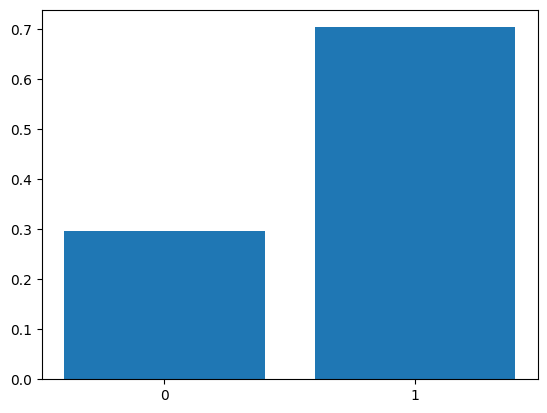

In [5]:
fig, ax = plt.subplots()
ax.bar(data_pmf.index, data_pmf)
ax.set_xticks([0, 1])
plt.show()

Looks about right.

## z-transformation using "normal" sampling

As you can see, CLT also works on binomial distribution.

In [6]:
means = [np.mean(np.random.choice(data, 100)) for _ in range(5000)]
bins = np.arange(np.min(means), np.max(means), 0.005)

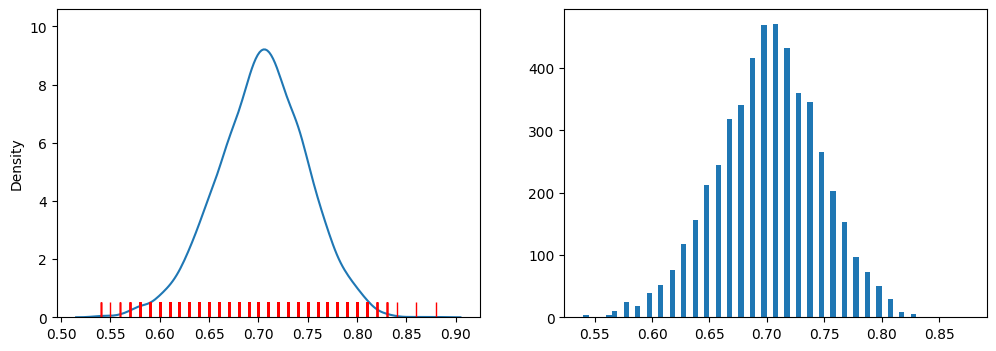

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(means, ax=ax[0])
sns.rugplot(means, color="red", height=0.05, ax=ax[0])
ax[1].hist(means, bins=bins, rwidth=0.9)
plt.show()

But does bootstraping work on binomial distribution?

In [8]:
sample = np.random.choice(data, 100)
means_bootstrap = [
    np.mean(np.random.choice(sample, len(sample), replace=True)) for _ in range(5000)
]
bins_bootstrap = np.arange(np.min(means_bootstrap), np.max(means_bootstrap), 0.005)

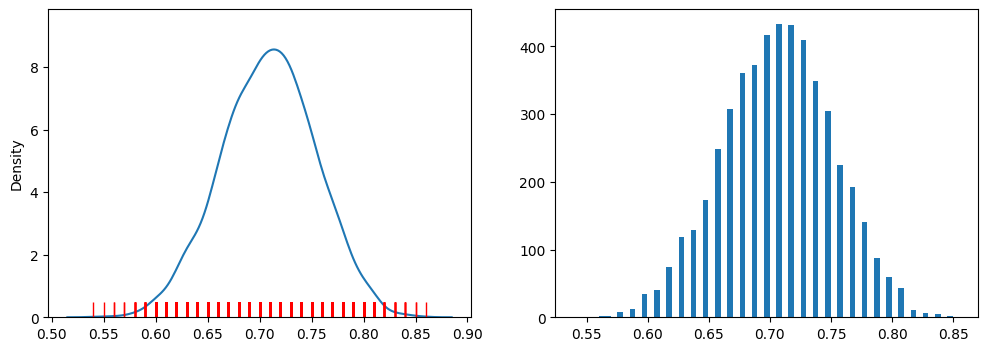

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(means_bootstrap, ax=ax[0])
sns.rugplot(means_bootstrap, color="red", height=0.05, ax=ax[0])
ax[1].hist(means_bootstrap, bins=bins_bootstrap, rwidth=0.9)
plt.show()

Yes, it works. Because bootstrap will work where the CLT works.